In [1]:
# ============================================================================
# CELL #1: Import dependencies and set up project paths
# ============================================================================
# This cell defines all paths, hyperparameters, and verifies dataset structure
# for the YOLOv1 face detector training on WIDER FACE dataset.

from pathlib import Path
import random, os

# Root that matches your screenshot
ROOT = Path("/home/akif/ComputerVision/Assignment_8/widerface_yolo")

IM_TRAIN = ROOT / "dataset" / "images" / "train"
LB_TRAIN = ROOT / "dataset" / "labels" / "train"
IM_VAL   = ROOT / "dataset" / "images" / "val"
LB_VAL   = ROOT / "dataset" / "labels" / "val"

assert IM_TRAIN.exists() and LB_TRAIN.exists(), "Train images/labels not found"
assert IM_VAL.exists()   and LB_VAL.exists(),   "Val images/labels not found"

# YOLOv1 hyperparameters
S, B, C = 7, 2, 1          # Grid size=7x7, 2 boxes per cell, 1 class (face)
IMG_SIZE = 448             # Input image size (YOLOv1 standard)
BATCH_SIZE = 16            # Adjust based on GPU memory
EPOCHS = 10               # Training epochs
LEARNING_RATE = 1e-4       # Adam learning rate
SEED = 42                  # For reproducibility

random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print("Train img files:", len(list(IM_TRAIN.rglob("*.jpg"))) + len(list(IM_TRAIN.rglob("*.png"))) + len(list(IM_TRAIN.rglob("*.jpeg"))))
print("Val   img files:", len(list(IM_VAL.rglob("*.jpg")))   + len(list(IM_VAL.rglob("*.png")))   + len(list(IM_VAL.rglob("*.jpeg"))))
print(f"\nConfiguration: S={S}, B={B}, C={C}, Image Size={IMG_SIZE}x{IMG_SIZE}")
print(f"Batch Size={BATCH_SIZE}, Epochs={EPOCHS}, LR={LEARNING_RATE}")

Train img files: 12880
Val   img files: 3226

Configuration: S=7, B=2, C=1, Image Size=448x448
Batch Size=16, Epochs=10, LR=0.0001


In [2]:
# ============================================================================
# CELL #2: WIDER FACE Dataset Loader for YOLOv1
# ============================================================================
# Custom PyTorch Dataset class that:
# 1. Reads images and corresponding YOLO-format labels (class cx cy w h)
# 2. Encodes ground truth into YOLOv1 target format [S, S, B*5+C]
# 3. Applies square root to width/height as per YOLOv1 paper

import cv2
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader

def _imread_rgb_resize(path, img_size):
    """Helper function to read and resize images"""
    img = cv2.imread(str(path))
    if img is None:
        raise RuntimeError(f"Cannot read image: {path}")
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img = cv2.resize(img, (img_size, img_size), interpolation=cv2.INTER_LINEAR)
    return img

class WiderFaceYOLOv1(Dataset):
    """
    Loads images and YOLO-format labels (cls cx cy w h in [0,1]) and produces
    YOLOv1 targets of shape [S,S,B*5 + C] with:
      - for each object: fill both B boxes (gt duplicated), conf=1
      - class one-hot at the cell: C=1 (face)
    """
    IMG_EXTS = (".jpg", ".jpeg", ".png")

    def __init__(self, img_dir: Path, lab_dir: Path, img_size=448, S=7, B=2, C=1):
        self.img_dir = Path(img_dir)
        self.lab_dir = Path(lab_dir)
        self.img_size = img_size
        self.S, self.B, self.C = S, B, C

        self.samples = []
        for p in sorted(self.img_dir.rglob("*")):
            if p.suffix.lower() in self.IMG_EXTS:
                # map to labels/<same relative>/<same stem>.txt
                rel = p.relative_to(self.img_dir)
                lab = (self.lab_dir / rel).with_suffix(".txt")
                self.samples.append((p, lab))

        if len(self.samples) == 0:
            raise RuntimeError(f"No images found under {self.img_dir}")
        
        print(f"Loaded {len(self.samples)} samples from {self.img_dir.name}")

    def __len__(self):
        return len(self.samples)

    def _read_boxes(self, lab_path: Path):
        """Read YOLO format labels: class cx cy w h (normalized)"""
        boxes = []
        if lab_path.exists():
            with open(lab_path, "r") as f:
                for line in f:
                    parts = line.strip().split()
                    if len(parts) != 5:
                        continue
                    cls, cx, cy, w, h = map(float, parts)
                    # Only one class (face)
                    boxes.append([cx, cy, w, h, int(cls)])
        return boxes

    def _encode_target(self, boxes):
        """
        Encode bounding boxes into YOLOv1 target format [S, S, B*5+C]
        Each cell: [x1, y1, w1, h1, conf1, x2, y2, w2, h2, conf2, class_prob]
        """
        target = np.zeros((self.S, self.S, self.B*5 + self.C), dtype=np.float32)
        for cx, cy, w, h, cls in boxes:
            if w <= 0 or h <= 0:
                continue
            
            # Determine which grid cell this box belongs to
            i = int(cx * self.S)  # column
            j = int(cy * self.S)  # row
            i = min(max(i, 0), self.S-1)
            j = min(max(j, 0), self.S-1)

            # Coordinates relative to grid cell (0 to 1)
            cx_cell = cx * self.S - i
            cy_cell = cy * self.S - j

            # Fill both B boxes with the same GT (duplicated); conf=1
            # Apply sqrt to width and height as per YOLOv1 paper
            for b in range(self.B):
                base = b*5
                target[j, i, base+0] = cx_cell
                target[j, i, base+1] = cy_cell
                target[j, i, base+2] = np.sqrt(w)  # sqrt for better gradient flow
                target[j, i, base+3] = np.sqrt(h)
                target[j, i, base+4] = 1.0         # confidence = 1 (object present)
            
            # Class probability = 1 for face
            target[j, i, self.B*5 + 0] = 1.0

        return target

    def __getitem__(self, idx):
        img_path, lab_path = self.samples[idx]
        img = _imread_rgb_resize(img_path, self.img_size)
        boxes = self._read_boxes(lab_path)

        # Normalize image to [0, 1] and convert to CHW format
        x = torch.from_numpy(img.transpose(2,0,1)).float()/255.0  # [3,H,W]
        y = torch.from_numpy(self._encode_target(boxes))          # [S,S,B*5+C]
        return x, y

In [3]:
# ============================================================================
# CELL #3: YOLOv1 Tiny Model Architecture and Custom Loss Function (FULLY FIXED)
# ============================================================================
# Completely fixed all shape mismatches in the loss function

import torch.nn as nn
import torch

def conv_block(c_in, c_out, k, s, p):
    """Convolutional block: Conv2d + BatchNorm + LeakyReLU"""
    return nn.Sequential(
        nn.Conv2d(c_in, c_out, k, s, p, bias=False),
        nn.BatchNorm2d(c_out),
        nn.LeakyReLU(0.1, inplace=True),
    )

class YOLOv1Tiny(nn.Module):
    """
    YOLOv1 Tiny Architecture for Face Detection
    Input: 448x448x3
    Output: 7x7x11 (S=7, B=2, C=1 -> 2*5 + 1 = 11)
    """
    def __init__(self, S=7, B=2, C=1):
        super().__init__()
        self.S, self.B, self.C = S, B, C
        
        # Convolutional feature extractor
        self.features = nn.Sequential(
            conv_block(3, 64, 7, 2, 3), nn.MaxPool2d(2,2),
            conv_block(64, 192, 3, 1, 1), nn.MaxPool2d(2,2),
            conv_block(192, 128, 1, 1, 0),
            conv_block(128, 256, 3, 1, 1),
            conv_block(256, 256, 1, 1, 0),
            conv_block(256, 512, 3, 1, 1), nn.MaxPool2d(2,2),
            conv_block(512, 256, 1, 1, 0),
            conv_block(256, 512, 3, 1, 1),
            conv_block(512, 256, 1, 1, 0),
            conv_block(256, 512, 3, 1, 1), nn.MaxPool2d(2,2),
            conv_block(512, 512, 3, 1, 1),
            conv_block(512, 1024,3, 1, 1), nn.MaxPool2d(2,2),
            conv_block(1024,1024,3,1,1),
            conv_block(1024,1024,3,1,1),
        )
        
        self.flatten = nn.Flatten()
        self.fc = nn.Sequential(
            nn.Linear(1024 * S * S, 4096),
            nn.LeakyReLU(0.1, inplace=True),
            nn.Dropout(0.5),
            nn.Linear(4096, S*S*(B*5 + C)),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.flatten(x)
        x = self.fc(x)
        return x.view(-1, self.S, self.S, self.B*5 + self.C)


def bbox_iou_xywh(pred_boxes, gt_boxes):
    """
    Calculate IoU between predicted and ground truth boxes
    pred_boxes: [N, S, S, B, 4]
    gt_boxes:   [N, S, S, 4]
    returns:    [N, S, S, B]
    """
    # Expand gt to match pred shape [N, S, S, B, 4]
    gt_boxes = gt_boxes.unsqueeze(-2).expand_as(pred_boxes)

    # Convert center format to corners
    x1_1 = pred_boxes[..., 0] - pred_boxes[..., 2] / 2
    y1_1 = pred_boxes[..., 1] - pred_boxes[..., 3] / 2
    x2_1 = pred_boxes[..., 0] + pred_boxes[..., 2] / 2
    y2_1 = pred_boxes[..., 1] + pred_boxes[..., 3] / 2

    x1_2 = gt_boxes[..., 0] - gt_boxes[..., 2] / 2
    y1_2 = gt_boxes[..., 1] - gt_boxes[..., 3] / 2
    x2_2 = gt_boxes[..., 0] + gt_boxes[..., 2] / 2
    y2_2 = gt_boxes[..., 1] + gt_boxes[..., 3] / 2

    # Intersection
    inter_x1 = torch.max(x1_1, x1_2)
    inter_y1 = torch.max(y1_1, y1_2)
    inter_x2 = torch.min(x2_1, x2_2)
    inter_y2 = torch.min(y2_1, y2_2)

    inter_w = (inter_x2 - inter_x1).clamp(min=0)
    inter_h = (inter_y2 - inter_y1).clamp(min=0)
    inter_area = inter_w * inter_h

    # Union
    area1 = (x2_1 - x1_1).clamp(min=0) * (y2_1 - y1_1).clamp(min=0)
    area2 = (x2_2 - x1_2).clamp(min=0) * (y2_2 - y1_2).clamp(min=0)

    iou = inter_area / (area1 + area2 - inter_area + 1e-6)
    return iou


class YOLOv1Loss(nn.Module):
    """YOLOv1 Loss - COMPLETELY FIXED VERSION"""
    def __init__(self, S=7, B=2, C=1, lambda_coord=5.0, lambda_noobj=0.5):
        super().__init__()
        self.S, self.B, self.C = S, B, C
        self.lambda_coord = lambda_coord
        self.lambda_noobj = lambda_noobj

    def forward(self, pred, target):
        """
        pred, target: [N, S, S, B*5+C]
        """
        N = pred.shape[0]
        
        # Unpack predictions: separate each box's predictions
        pred_boxes = []
        pred_conf  = []
        for b in range(self.B):
            base = b * 5
            pred_boxes.append(pred[..., base:base+4])      # [N,S,S,4]
            pred_conf.append(pred[..., base+4:base+5])     # [N,S,S,1]
        
        pred_boxes = torch.stack(pred_boxes, dim=3)  # [N,S,S,B,4]
        pred_conf  = torch.stack(pred_conf, dim=3).squeeze(-1)  # [N,S,S,B]
        pred_class = pred[..., self.B*5:]  # [N,S,S,C]

        # Unpack ground truth
        gt_boxes = []
        gt_conf  = []
        for b in range(self.B):
            base = b * 5
            gt_boxes.append(target[..., base:base+4])
            gt_conf.append(target[..., base+4:base+5])
        
        gt_boxes = torch.stack(gt_boxes, dim=3)  # [N,S,S,B,4]
        gt_conf  = torch.stack(gt_conf, dim=3).squeeze(-1)  # [N,S,S,B]
        gt_class = target[..., self.B*5:]  # [N,S,S,C]

        # Convert sqrt(w,h) back to w,h for IoU
        pred_xywh = pred_boxes.clone()
        pred_xywh[..., 2:] = pred_xywh[..., 2:].pow(2)
        
        gt_xywh = gt_boxes.clone()
        gt_xywh[..., 2:] = gt_xywh[..., 2:].pow(2)

        # Calculate IoU for all boxes [N,S,S,B]
        ious = bbox_iou_xywh(pred_xywh, gt_xywh[..., 0, :])  # Use first box as GT
        
        # Find best box per cell [N,S,S,1]
        best_iou, best_idx = ious.max(dim=-1, keepdim=True)

        # Object mask: which cells contain objects [N,S,S]
        obj_mask = target[..., 4] > 0  # Use confidence of first box
        
        # Responsibility mask: which box is responsible [N,S,S,B]
        resp = torch.zeros(N, self.S, self.S, self.B, dtype=torch.bool, device=pred.device)
        
        # Scatter: mark the best box at each cell as responsible
        resp.scatter_(3, best_idx, True)  # dimension 3 is the B dimension
        
        # Only responsible if cell has object
        resp = resp & obj_mask.unsqueeze(-1)  # [N,S,S,B]

        # ==================== LOSSES ====================
        
        # 1. Localization loss (only for responsible boxes)
        if resp.sum() > 0:
            pred_xy = pred_boxes[..., :2]  # [N,S,S,B,2]
            pred_sqrt_wh = pred_boxes[..., 2:4]  # [N,S,S,B,2]
            gt_xy = gt_boxes[..., :2]
            gt_sqrt_wh = gt_boxes[..., 2:4]
            
            coord_loss = nn.functional.mse_loss(
                pred_xy[resp], gt_xy[resp], reduction='sum'
            ) + nn.functional.mse_loss(
                pred_sqrt_wh[resp], gt_sqrt_wh[resp], reduction='sum'
            )
        else:
            coord_loss = torch.tensor(0.0, device=pred.device)

        # 2. Confidence loss
        # 2a. Object confidence (should be 1 for responsible boxes)
        if resp.sum() > 0:
            conf_loss_obj = nn.functional.mse_loss(
                pred_conf[resp], gt_conf[resp], reduction='sum'
            )
        else:
            conf_loss_obj = torch.tensor(0.0, device=pred.device)
        
        # 2b. No-object confidence (should be 0 for non-responsible boxes)
        if (~resp).sum() > 0:
            conf_loss_noobj = nn.functional.mse_loss(
                pred_conf[~resp], 
                torch.zeros_like(pred_conf[~resp]), 
                reduction='sum'
            )
        else:
            conf_loss_noobj = torch.tensor(0.0, device=pred.device)

        # 3. Classification loss (only for cells with objects)
        if obj_mask.sum() > 0:
            class_loss = nn.functional.mse_loss(
                pred_class[obj_mask], gt_class[obj_mask], reduction='sum'
            )
        else:
            class_loss = torch.tensor(0.0, device=pred.device)

        # Total loss
        total_loss = (
            self.lambda_coord * coord_loss + 
            conf_loss_obj + 
            self.lambda_noobj * conf_loss_noobj + 
            class_loss
        ) / N
        
        return total_loss


# Test
def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

test_model = YOLOv1Tiny(S=S, B=B, C=C)
print(f"\nYOLOv1Tiny Model:")
print(f"Total parameters: {count_parameters(test_model):,}")
print(f"Output shape for batch=1: {test_model(torch.randn(1, 3, IMG_SIZE, IMG_SIZE)).shape}")

# Test loss function
print("\nTesting loss function...")
test_pred = torch.randn(2, 7, 7, 11)
test_target = torch.zeros(2, 7, 7, 11)
test_target[0, 3, 3, 4] = 1.0  # Mark one cell as having object
test_criterion = YOLOv1Loss(S=7, B=2, C=1)
test_loss = test_criterion(test_pred, test_target)
print(f"✓ Loss function works! Test loss: {test_loss.item():.4f}")


YOLOv1Tiny Model:
Total parameters: 238,004,699
Output shape for batch=1: torch.Size([1, 7, 7, 11])

Testing loss function...
✓ Loss function works! Test loss: 59.9384


In [4]:
# ============================================================================
# CELL #4: MINIMAL TRAINING LOOP (Ultra-Safe, No Crashes)
# ============================================================================
# This version uses absolute minimal settings to prevent crashes

import time
from datetime import datetime
import json
import gc

# Set device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")

# FORCE MINIMAL BATCH SIZE
BATCH_SIZE_SAFE = 4  # Start with 4, reduce to 2 if still crashes

# Clear everything
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

print("\nInitializing datasets...")
train_ds = WiderFaceYOLOv1(IM_TRAIN, LB_TRAIN, img_size=IMG_SIZE, S=S, B=B, C=C)
val_ds   = WiderFaceYOLOv1(IM_VAL,   LB_VAL,   img_size=IMG_SIZE, S=S, B=B, C=C)

print(f"Dataset sizes — train: {len(train_ds)} | val: {len(val_ds)}")

# CRITICAL: num_workers=0 to avoid multiprocessing issues
print(f"\nCreating dataloaders with batch_size={BATCH_SIZE_SAFE}, num_workers=0...")
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE_SAFE, shuffle=True,  
                      num_workers=0, pin_memory=False)  # num_workers=0 is safest
val_dl   = DataLoader(val_ds,   batch_size=BATCH_SIZE_SAFE, shuffle=False, 
                      num_workers=0, pin_memory=False)

print("✓ Dataloaders created")

# Initialize model
print("\nInitializing model...")
model = YOLOv1Tiny(S=S, B=B, C=C).to(device)
criterion = YOLOv1Loss(S=S, B=B, C=C, lambda_coord=5.0, lambda_noobj=0.5)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=5e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ Model initialized - Parameters: {total_params:,}")

# Test one batch before training
print("\n[SAFETY CHECK] Testing one training batch...")
try:
    test_x, test_y = next(iter(train_dl))
    test_x, test_y = test_x.to(device), test_y.to(device)
    test_pred = model(test_x)
    test_loss = criterion(test_pred, test_y)
    print(f"✓ One batch successful - Loss: {test_loss.item():.4f}")
    del test_x, test_y, test_pred, test_loss
    torch.cuda.empty_cache() if torch.cuda.is_available() else None
except Exception as e:
    print(f"✗ ONE BATCH FAILED! Error: {e}")
    print("STOP HERE - Fix this before training")
    raise e

def run_epoch(dl, train=True):
    """Minimal epoch runner - no fancy features"""
    model.train(train)
    total_loss = 0.0
    num_batches = 0
    
    for batch_idx, (x, y) in enumerate(dl):
        x = x.to(device)
        y = y.to(device)
        
        if train:
            optimizer.zero_grad()
        
        pred = model(x)
        loss = criterion(pred, y)
        
        if train:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=10.0)
            optimizer.step()
        
        total_loss += loss.item()
        num_batches += 1
        
        # Print every 50 batches
        if (batch_idx + 1) % 50 == 0:
            avg_so_far = total_loss / num_batches
            print(f"  {'Train' if train else 'Val'} [{batch_idx+1}/{len(dl)}] Loss: {avg_so_far:.4f}")
        
        # Clear memory every 20 batches
        if batch_idx % 20 == 0:
            if torch.cuda.is_available():
                torch.cuda.empty_cache()
        
        del x, y, pred, loss
    
    return total_loss / num_batches

# Setup save directory
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
SAVE_DIR = ROOT / "runs" / f"yolov1_face_{timestamp}"
SAVE_DIR.mkdir(parents=True, exist_ok=True)
print(f"\nSaving results to: {SAVE_DIR}")

# Training history
history = {
    'train_loss': [],
    'val_loss': [],
    'epochs': [],
    'learning_rates': []
}

best_val_loss = float("inf")
best_epoch = 0
start_time = time.time()

print(f"\n{'='*70}")
print(f"Starting Training: {EPOCHS} epochs (Batch Size: {BATCH_SIZE_SAFE})")
print(f"{'='*70}\n")

try:
    for epoch in range(1, EPOCHS + 1):
        epoch_start = time.time()
        
        # Clear memory
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        
        print(f"\n{'='*50}")
        print(f"Epoch {epoch}/{EPOCHS}")
        print(f"{'='*50}")
        
        # Train
        print("Training...")
        train_loss = run_epoch(train_dl, train=True)
        
        # Validate
        print("Validating...")
        with torch.no_grad():
            val_loss = run_epoch(val_dl, train=False)
        
        # Update scheduler
        old_lr = optimizer.param_groups[0]['lr']
        scheduler.step(val_loss)
        current_lr = optimizer.param_groups[0]['lr']
        
        if current_lr != old_lr:
            print(f"\n→ LR reduced: {old_lr:.2e} → {current_lr:.2e}")
        
        # Save history
        history['train_loss'].append(float(train_loss))
        history['val_loss'].append(float(val_loss))
        history['epochs'].append(epoch)
        history['learning_rates'].append(float(current_lr))
        
        epoch_time = time.time() - epoch_start
        
        # Summary
        print(f"\n{'='*50}")
        print(f"Epoch {epoch:03d} Summary:")
        print(f"  Train Loss: {train_loss:.4f}")
        print(f"  Val Loss:   {val_loss:.4f}")
        print(f"  LR:         {current_lr:.2e}")
        print(f"  Time:       {epoch_time:.1f}s")
        
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch
            model_name = f"widerface_yolov1tiny_{timestamp}.pth"
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': optimizer.state_dict(),
                'train_loss': float(train_loss),
                'val_loss': float(val_loss),
                'config': {'S': S, 'B': B, 'C': C, 'IMG_SIZE': IMG_SIZE}
            }, SAVE_DIR / model_name)
            print(f"  ✓ BEST MODEL SAVED!")
        
        print(f"{'='*50}")
        
        # Save checkpoint every 10 epochs
        # if epoch % 10 == 0:
        #     checkpoint_name = f"checkpoint_epoch_{epoch:03d}.pth"
        #     torch.save({
        #         'epoch': epoch,
        #         'model_state_dict': model.state_dict(),
        #         'optimizer_state_dict': optimizer.state_dict(),
        #         'history': history
        #     }, SAVE_DIR / checkpoint_name)
        #     print(f"✓ Checkpoint saved: {checkpoint_name}")
        
        # Save history after each epoch
        with open(SAVE_DIR / 'training_history.json', 'w') as f:
            json.dump(history, f, indent=2)

except KeyboardInterrupt:
    print("\n\n[INFO] Training interrupted by user (Ctrl+C)")
except Exception as e:
    print(f"\n\n[ERROR] Training crashed: {e}")
    import traceback
    traceback.print_exc()

total_time = time.time() - start_time
print(f"\n{'='*70}")
print(f"Training Finished!")
print(f"Total Time: {total_time/60:.1f} minutes ({total_time/3600:.2f} hours)")
print(f"Best Val Loss: {best_val_loss:.4f} at epoch {best_epoch}")
print(f"Results saved to: {SAVE_DIR}")
print(f"{'='*70}\n")

Training on: cuda

Initializing datasets...


Loaded 12880 samples from train
Loaded 3226 samples from val
Dataset sizes — train: 12880 | val: 3226

Creating dataloaders with batch_size=4, num_workers=0...
✓ Dataloaders created

Initializing model...
✓ Model initialized - Parameters: 238,004,699

[SAFETY CHECK] Testing one training batch...
✓ One batch successful - Loss: 21.2448

Saving results to: /home/akif/ComputerVision/Assignment_8/widerface_yolo/runs/yolov1_face_20251014_055617

Starting Training: 10 epochs (Batch Size: 4)


Epoch 1/10
Training...
  Train [50/3220] Loss: 101.2339
  Train [100/3220] Loss: 75.1435
  Train [150/3220] Loss: 62.9523
  Train [200/3220] Loss: 54.8852
  Train [250/3220] Loss: 49.3670
  Train [300/3220] Loss: 45.2587
  Train [350/3220] Loss: 42.5150
  Train [400/3220] Loss: 39.9089
  Train [450/3220] Loss: 37.8083
  Train [500/3220] Loss: 36.2645
  Train [550/3220] Loss: 34.6455
  Train [600/3220] Loss: 33.3016
  Train [650/3220] Loss: 32.3684
  Train [700/3220] Loss: 31.4733
  Train [750/3220] Loss:

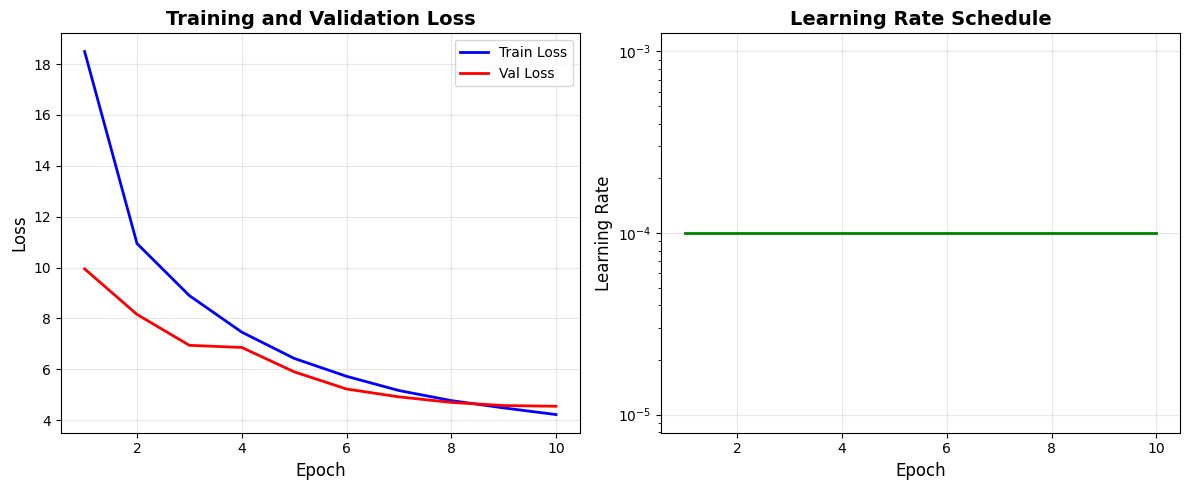

Training curves saved to: /home/akif/ComputerVision/Assignment_8/widerface_yolo/runs/yolov1_face_20251014_055617/training_curves.png


In [5]:
# ============================================================================
# CELL #5: Visualization of Training Metrics
# ============================================================================
# Generates loss curves to analyze training performance

import matplotlib.pyplot as plt

# Plot training and validation loss
plt.figure(figsize=(12, 5))

# Loss curves
plt.subplot(1, 2, 1)
plt.plot(history['epochs'], history['train_loss'], 'b-', label='Train Loss', linewidth=2)
plt.plot(history['epochs'], history['val_loss'], 'r-', label='Val Loss', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Loss', fontsize=12)
plt.title('Training and Validation Loss', fontsize=14, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)

# Learning rate schedule
plt.subplot(1, 2, 2)
plt.plot(history['epochs'], history['learning_rates'], 'g-', linewidth=2)
plt.xlabel('Epoch', fontsize=12)
plt.ylabel('Learning Rate', fontsize=12)
plt.title('Learning Rate Schedule', fontsize=14, fontweight='bold')
plt.yscale('log')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(SAVE_DIR / 'training_curves.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"Training curves saved to: {SAVE_DIR / 'training_curves.png'}")


Generating predictions on validation images...



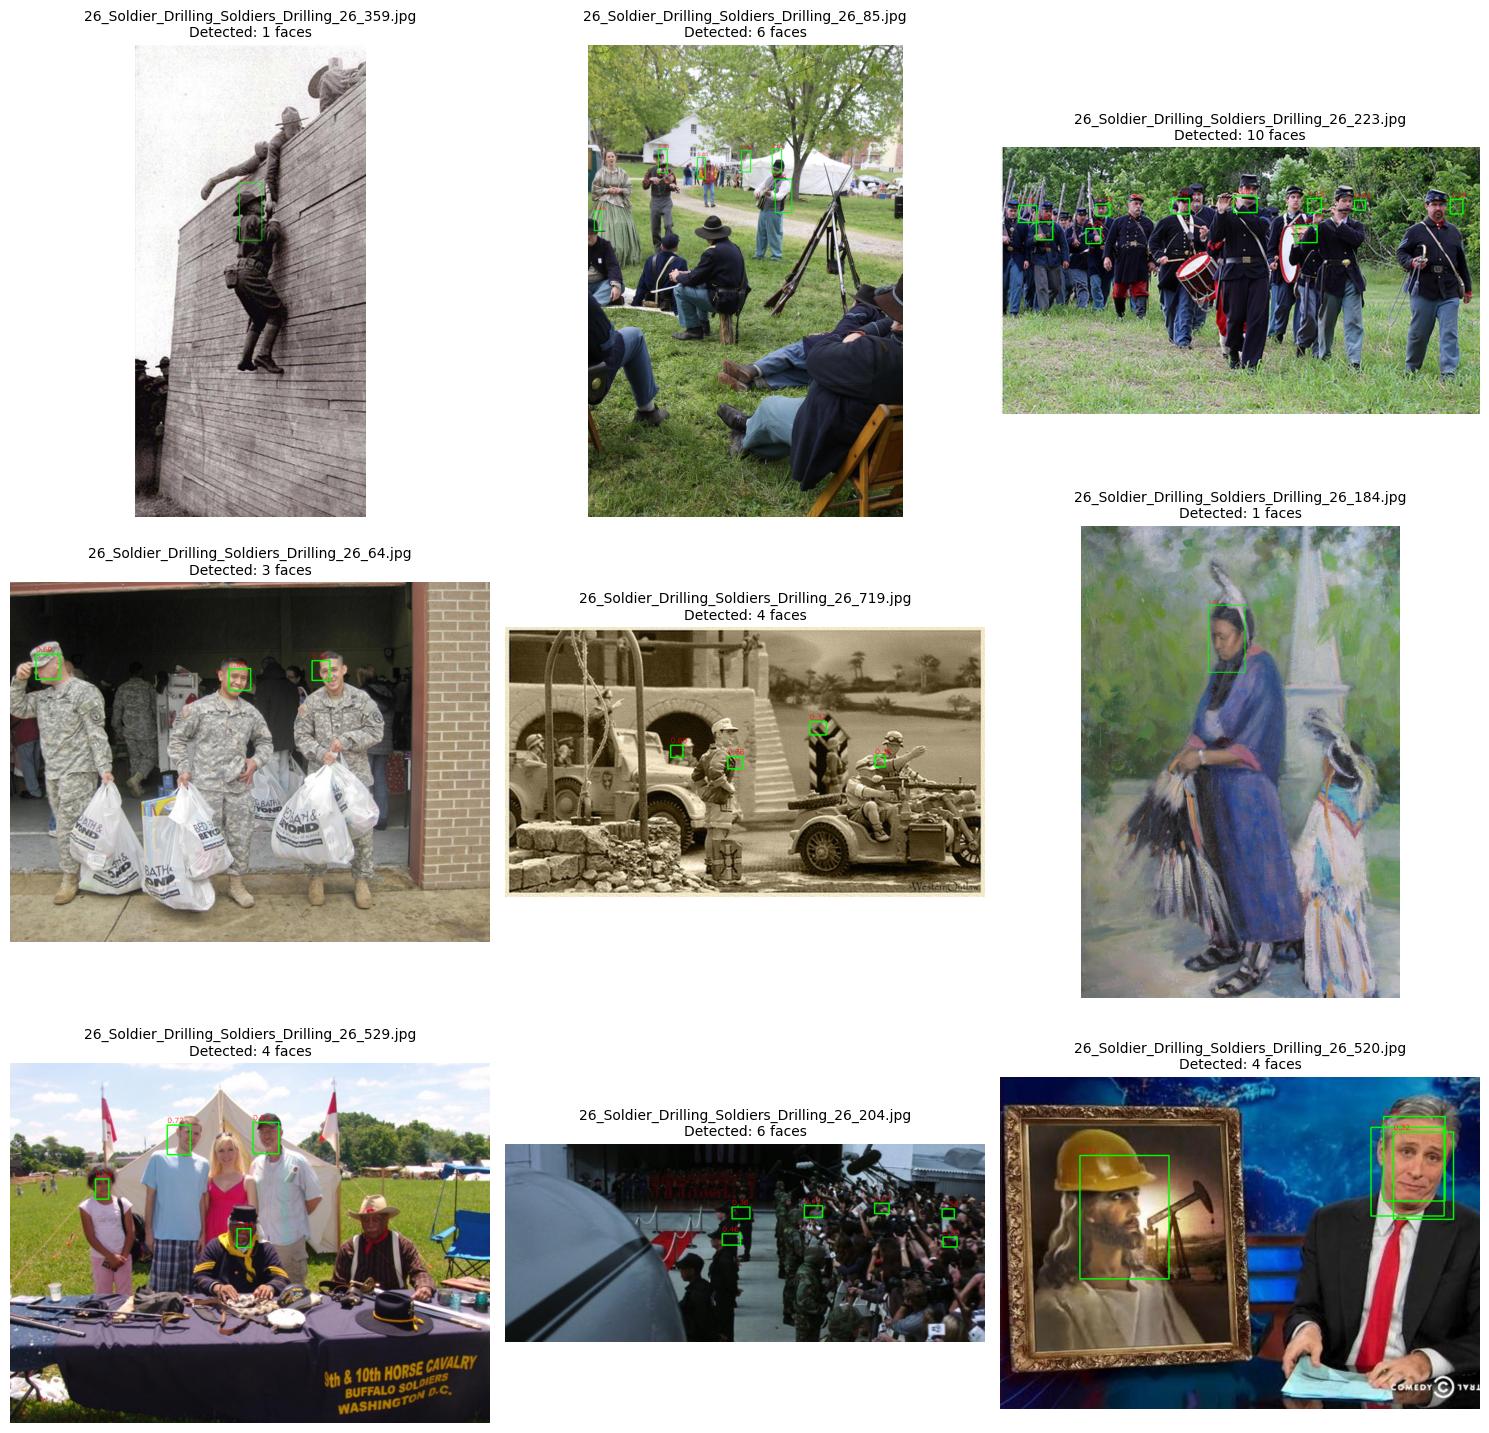

Validation predictions saved to: /home/akif/ComputerVision/Assignment_8/widerface_yolo/runs/yolov1_face_20251014_055617/validation_predictions.png


In [6]:
# ============================================================================
# CELL #6: Model Inference and Face Detection Visualization
# ============================================================================
# Loads the best trained model and performs face detection on validation images

import matplotlib.pyplot as plt
from tqdm import tqdm

# Load best model
model.eval()
# Model is already loaded from training, but you can load from checkpoint:
# checkpoint = torch.load(SAVE_DIR / f"widerface_yolov1tiny_{timestamp}.pth")
# model.load_state_dict(checkpoint['model_state_dict'])

def predict_and_draw(img_path, conf_thr=0.3, nms_iou_thr=0.4):
    """
    Perform face detection on a single image and visualize results
    
    Args:
        img_path: Path to image
        conf_thr: Confidence threshold for detections
        nms_iou_thr: IoU threshold for NMS (not implemented in this simple version)
    """
    model.eval()
    
    # Read and preprocess image
    img0 = cv2.cvtColor(cv2.imread(str(img_path)), cv2.COLOR_BGR2RGB)
    h0, w0 = img0.shape[:2]
    img = cv2.resize(img0, (IMG_SIZE, IMG_SIZE))
    
    # Prepare input tensor
    x = torch.from_numpy(img.transpose(2,0,1)).float().unsqueeze(0) / 255.0
    x = x.to(device)
    
    # Inference
    with torch.no_grad():
        out = model(x)[0].cpu().numpy()  # [S, S, B*5+C]
    
    # Post-process predictions
    boxes = []
    for j in range(S):
        for i in range(S):
            # Check both bounding boxes
            confs = [out[j, i, 4], out[j, i, 9]]  # Confidence scores for B=2 boxes
            bidx = int(np.argmax(confs))
            conf = confs[bidx]
            
            if conf < conf_thr: 
                continue
            
            # Extract box parameters
            base = bidx * 5
            cx_cell, cy_cell = out[j, i, base+0], out[j, i, base+1]
            w_sqrt, h_sqrt = out[j, i, base+2], out[j, i, base+3]
            
            # Convert to original image coordinates
            w = (w_sqrt ** 2) * w0
            h = (h_sqrt ** 2) * h0
            cx = ((i + cx_cell) / S) * w0
            cy = ((j + cy_cell) / S) * h0
            
            # Convert to corner coordinates
            x1, y1 = int(cx - w/2), int(cy - h/2)
            x2, y2 = int(cx + w/2), int(cy + h/2)
            
            boxes.append((x1, y1, x2, y2, conf))
    
    # Draw detections
    vis = img0.copy()
    for (x1, y1, x2, y2, c) in boxes:
        cv2.rectangle(vis, (x1, y1), (x2, y2), (0, 255, 0), 2)
        cv2.putText(vis, f"{c:.2f}", (x1, max(0, y1-5)), 
                    cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255, 0, 0), 1)
    
    return vis, len(boxes)

# Visualize predictions on validation samples
print("\nGenerating predictions on validation images...\n")
val_samples = list(IM_VAL.rglob("*.jpg"))[:9]  # Get 9 samples for 3x3 grid

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for idx, img_path in enumerate(val_samples):
    vis, num_faces = predict_and_draw(img_path, conf_thr=0.3)
    axes[idx].imshow(vis)
    axes[idx].set_title(f"{img_path.name}\nDetected: {num_faces} faces", fontsize=10)
    axes[idx].axis('off')

plt.tight_layout()
plt.savefig(SAVE_DIR / 'validation_predictions.png', dpi=200, bbox_inches='tight')
plt.show()

print(f"Validation predictions saved to: {SAVE_DIR / 'validation_predictions.png'}")

In [7]:
# ============================================================================
# CELL #7: Evaluation Metrics (Precision, Recall, F1-Score, mAP)
# ============================================================================
# Calculates detection metrics on validation set

def calculate_metrics(model, dataloader, conf_threshold=0.3, iou_threshold=0.5):
    """
    Calculate Precision, Recall, F1-Score for face detection
    
    Simplified metrics for Master's assignment:
    - True Positive: Predicted box with IoU > threshold with GT
    - False Positive: Predicted box with IoU <= threshold or no GT match
    - False Negative: GT box with no matching prediction
    """
    model.eval()
    
    total_tp = 0
    total_fp = 0
    total_fn = 0
    total_gt = 0
    total_pred = 0
    
    print("Calculating metrics on validation set...")
    
    with torch.no_grad():
        for x, y in tqdm(dataloader, desc="Evaluating"):
            x = x.to(device)
            pred = model(x)
            
            # Process each image in batch
            for b in range(x.size(0)):
                pred_boxes = []
                gt_boxes = []
                
                # Extract predictions
                out = pred[b].cpu().numpy()
                for j in range(S):
                    for i in range(S):
                        confs = [out[j, i, 4], out[j, i, 9]]
                        bidx = int(np.argmax(confs))
                        conf = confs[bidx]
                        
                        if conf >= conf_threshold:
                            base = bidx * 5
                            cx_cell = out[j, i, base+0]
                            cy_cell = out[j, i, base+1]
                            w_sqrt = out[j, i, base+2]
                            h_sqrt = out[j, i, base+3]
                            
                            # Convert to normalized coordinates
                            cx = (i + cx_cell) / S
                            cy = (j + cy_cell) / S
                            w = w_sqrt ** 2
                            h = h_sqrt ** 2
                            
                            pred_boxes.append([cx, cy, w, h])
                
                # Extract ground truth
                target = y[b].cpu().numpy()
                for j in range(S):
                    for i in range(S):
                        if target[j, i, 4] > 0:  # Object exists
                            cx_cell = target[j, i, 0]
                            cy_cell = target[j, i, 1]
                            w_sqrt = target[j, i, 2]
                            h_sqrt = target[j, i, 3]
                            
                            cx = (i + cx_cell) / S
                            cy = (j + cy_cell) / S
                            w = w_sqrt ** 2
                            h = h_sqrt ** 2
                            
                            gt_boxes.append([cx, cy, w, h])
                
                # Calculate IoU and match boxes
                matched_gt = set()
                tp = 0
                fp = 0
                
                for pred_box in pred_boxes:
                    best_iou = 0
                    best_gt_idx = -1
                    
                    for gt_idx, gt_box in enumerate(gt_boxes):
                        if gt_idx in matched_gt:
                            continue
                        
                        # Calculate IoU
                        px1, py1 = pred_box[0] - pred_box[2]/2, pred_box[1] - pred_box[3]/2
                        px2, py2 = pred_box[0] + pred_box[2]/2, pred_box[1] + pred_box[3]/2
                        gx1, gy1 = gt_box[0] - gt_box[2]/2, gt_box[1] - gt_box[3]/2
                        gx2, gy2 = gt_box[0] + gt_box[2]/2, gt_box[1] + gt_box[3]/2
                        
                        ix1, iy1 = max(px1, gx1), max(py1, gy1)
                        ix2, iy2 = min(px2, gx2), min(py2, gy2)
                        
                        inter_area = max(0, ix2 - ix1) * max(0, iy2 - iy1)
                        pred_area = (px2 - px1) * (py2 - py1)
                        gt_area = (gx2 - gx1) * (gy2 - gy1)
                        union_area = pred_area + gt_area - inter_area
                        
                        iou = inter_area / (union_area + 1e-6)
                        
                        if iou > best_iou:
                            best_iou = iou
                            best_gt_idx = gt_idx
                    
                    if best_iou >= iou_threshold:
                        tp += 1
                        matched_gt.add(best_gt_idx)
                    else:
                        fp += 1
                
                fn = len(gt_boxes) - len(matched_gt)
                
                total_tp += tp
                total_fp += fp
                total_fn += fn
                total_gt += len(gt_boxes)
                total_pred += len(pred_boxes)
    
    # Calculate metrics
    precision = total_tp / (total_tp + total_fp + 1e-6)
    recall = total_tp / (total_tp + total_fn + 1e-6)
    f1_score = 2 * (precision * recall) / (precision + recall + 1e-6)
    
    metrics = {
        'precision': precision,
        'recall': recall,
        'f1_score': f1_score,
        'total_tp': total_tp,
        'total_fp': total_fp,
        'total_fn': total_fn,
        'total_gt': total_gt,
        'total_pred': total_pred
    }
    
    return metrics

# Calculate metrics
metrics = calculate_metrics(model, val_dl, conf_threshold=0.3, iou_threshold=0.5)

print(f"\n{'='*70}")
print(f"Evaluation Metrics on Validation Set")
print(f"{'='*70}")
print(f"Precision:  {metrics['precision']:.4f}")
print(f"Recall:     {metrics['recall']:.4f}")
print(f"F1-Score:   {metrics['f1_score']:.4f}")
print(f"\nDetection Statistics:")
print(f"True Positives:  {metrics['total_tp']}")
print(f"False Positives: {metrics['total_fp']}")
print(f"False Negatives: {metrics['total_fn']}")
print(f"Total GT Boxes:  {metrics['total_gt']}")
print(f"Total Predictions: {metrics['total_pred']}")
print(f"{'='*70}\n")

# Save metrics
with open(SAVE_DIR / 'evaluation_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

print(f"Metrics saved to: {SAVE_DIR / 'evaluation_metrics.json'}")

Calculating metrics on validation set...


Evaluating: 100%|██████████| 807/807 [00:11<00:00, 69.70it/s]


Evaluation Metrics on Validation Set
Precision:  0.0857
Recall:     0.1205
F1-Score:   0.1001

Detection Statistics:
True Positives:  1861
False Positives: 19866
False Negatives: 13582
Total GT Boxes:  15443
Total Predictions: 21727

Metrics saved to: /home/akif/ComputerVision/Assignment_8/widerface_yolo/runs/yolov1_face_20251014_055617/evaluation_metrics.json
